# LRB 03 — Logistic Regression Evaluation

Review standardized Peak-Risk metrics.

In [4]:
# Import libraries
from pathlib import Path
import sys
import matplotlib.pyplot as plt

In [5]:
# Define the root directory of the project and config file
PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / "src").exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

CONFIG_PATH = PROJECT_ROOT / "configs" / "logistic_regression_peak_baseline.yaml"
CONFIG_PATH

WindowsPath('e:/jcuenca/OneDrive - GUSCanada/5toTerm/01_Capstone/Codigo/ontario-electricity-peak-risk/configs/logistic_regression_peak_baseline.yaml')

In [6]:
# Import module to run baseline model
from src.ontario_peak_risk.models.peak_risk.logistic_regression.run_baseline import (
    run_logistic_regression_peak_baseline,
)

In [7]:
# Run the baseline model - logistic regression
results = run_logistic_regression_peak_baseline(CONFIG_PATH)

Logistic Regression Peak-Risk baseline completed successfully.
Development folds evaluated: ['fold_2023', 'fold_2024']
Final 2025 holdout evaluated: NO
Reports: E:\jcuenca\OneDrive - GUSCanada\5toTerm\01_Capstone\Codigo\ontario-electricity-peak-risk\reports\modeling\peak_risk\logistic_regression


In [8]:
# Display results
results["class_balance"]

,fold,horizon,observations,peak_hours,peak_rate_pct
0,fold_2023,1,52416,5743,10.956578
1,fold_2023,2,52416,5743,10.956578
2,fold_2023,3,52416,5743,10.956578
3,fold_2023,4,52416,5743,10.956578
4,fold_2023,5,52416,5743,10.956578
5,fold_2023,6,52416,5743,10.956578
6,fold_2023,7,52416,5743,10.956578
7,fold_2023,8,52416,5743,10.956578
8,fold_2023,9,52416,5743,10.956578
9,fold_2023,10,52416,5743,10.956578


In [9]:
# Display results - Global metrics
results["global_metrics"]

,model,precision,recall,f1,balanced_accuracy,n_observations,positive_rate_pct,pr_auc,roc_auc
0,logistic_regression_peak_baseline,0.843267,0.306492,0.449581,0.650943,2519424,7.482544,0.675276,0.943635


In [10]:
# Display results - fold metrics
results["fold_metrics"]

,fold,precision,recall,f1,balanced_accuracy,n_observations,positive_rate_pct,pr_auc,roc_auc
0,fold_2023,0.898704,0.321783,0.473888,0.658658,1257984,10.965243,0.744155,0.941553
1,fold_2024,0.700125,0.264790,0.384253,0.630026,1261440,4.009386,0.538786,0.954540


In [11]:
# Display results - FSA metrics
results["fsa_metrics"]

,fold,fsa,precision,recall,f1,balanced_accuracy,n_observations,positive_rate_pct,pr_auc,roc_auc
0,fold_2023,L4T,0.641026,0.301205,0.409836,0.648969,209664,1.900183,0.486614,0.955111
1,fold_2023,M5R,0.956522,0.127907,0.225641,0.563895,209664,1.968864,0.447844,0.942510
2,fold_2023,M5S,0.000000,0.000000,0.000000,0.500000,209664,1.579670,0.308086,0.908243
3,fold_2023,M6G,0.793991,0.158282,0.263946,0.577929,209664,5.574634,0.557682,0.940145
4,fold_2023,M9R,0.853659,0.119098,0.209033,0.559194,209664,3.363954,0.525227,0.945236
5,fold_2023,M9W,0.915628,0.370853,0.527894,0.667352,209664,51.404151,0.884445,0.912276
6,fold_2024,L4T,0.443787,0.306122,0.362319,0.647542,210240,2.796804,0.367107,0.961234
7,fold_2024,M5R,1.000000,0.040816,0.078431,0.520408,210240,1.678082,0.358726,0.954313
8,fold_2024,M5S,0.000000,0.000000,0.000000,0.500000,210240,1.358447,0.130632,0.828548
9,fold_2024,M6G,0.793103,0.288401,0.422989,0.642779,210240,3.641553,0.594286,0.971071


In [12]:
# Display results - horizon metrics
results["horizon_metrics"]

,fold,horizon,precision,recall,f1,balanced_accuracy,n_observations,positive_rate_pct,pr_auc,roc_auc
0,fold_2023,1,0.898346,0.321609,0.473650,0.658565,52416,10.956578,0.743678,0.941466
1,fold_2023,2,0.898346,0.321609,0.473650,0.658565,52416,10.956578,0.743711,0.941477
2,fold_2023,3,0.898346,0.321609,0.473650,0.658565,52416,10.956578,0.743740,0.941487
3,fold_2023,4,0.898346,0.321609,0.473650,0.658565,52416,10.956578,0.743764,0.941496
4,fold_2023,5,0.898346,0.321609,0.473650,0.658565,52416,10.956578,0.743786,0.941505
5,fold_2023,6,0.898346,0.321609,0.473650,0.658565,52416,10.956578,0.743808,0.941513
6,fold_2023,7,0.898346,0.321609,0.473650,0.658565,52416,10.956578,0.743832,0.941522
7,fold_2023,8,0.898346,0.321609,0.473650,0.658565,52416,10.956578,0.743858,0.941532
8,fold_2023,9,0.898396,0.321783,0.473846,0.658653,52416,10.956578,0.743889,0.941542
9,fold_2023,10,0.898396,0.321783,0.473846,0.658653,52416,10.956578,0.743924,0.941553


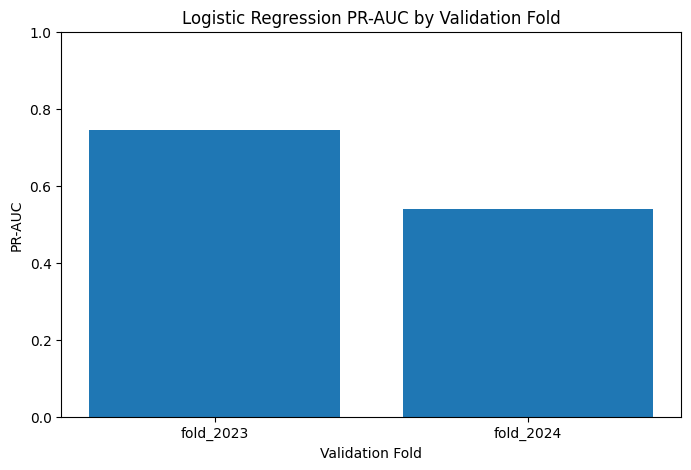

In [13]:
# Plot PR-AUC by validation fold

fold_metrics = results["fold_metrics"]

plt.figure(figsize=(8, 5))

plt.bar(
    fold_metrics["fold"],
    fold_metrics["pr_auc"],
)

plt.xlabel("Validation Fold")
plt.ylabel("PR-AUC")
plt.title("Logistic Regression PR-AUC by Validation Fold")

plt.ylim(0, 1)

plt.show()

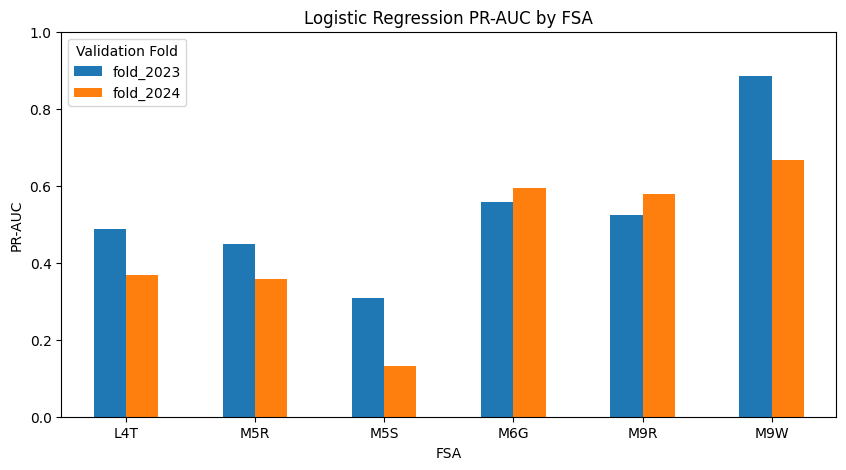

In [14]:
# Plot PR-AUC by FSA and validation fold
fsa_metrics = results["fsa_metrics"]

pivot_fsa = fsa_metrics.pivot(
    index="fsa",
    columns="fold",
    values="pr_auc",
)

pivot_fsa.plot(
    kind="bar",
    figsize=(10, 5),
)

plt.xlabel("FSA")
plt.ylabel("PR-AUC")
plt.title("Logistic Regression PR-AUC by FSA")

plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.legend(title="Validation Fold")

plt.show()

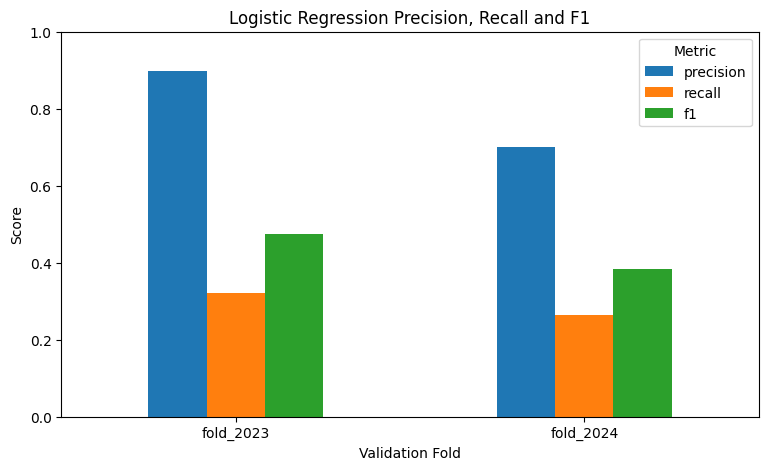

In [15]:
# Compare Precision and Recall by validation fold
fold_metrics = results["fold_metrics"]

plot_data = fold_metrics.set_index("fold")[
    ["precision", "recall", "f1"]
]

plot_data.plot(
    kind="bar",
    figsize=(9, 5),
)

plt.xlabel("Validation Fold")
plt.ylabel("Score")
plt.title(
    "Logistic Regression Precision, Recall and F1"
)

plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Metric")

plt.show()